# 🔍 Relational Fraud Detection
### Graph Neural Network on Heterogeneous Transaction Graphs

---

**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Task:** Binary Node Classification — Fraud vs. Legitimate  
**Target:** `isFraud` (0 = Legitimate, 1 = Fraud)  
**Framework:** PyTorch — implemented from scratch


---
## Phase 01 — Data Preprocessing

**Goal:** Load the raw data, clean it, and prepare it so we can build a graph from it in Phase 03.

The IEEE-CIS dataset comes in two separate files — one for transactions and one for identity/device info. Our job here is to merge them, handle missing values, encode categories, and identify which columns will later become nodes in our graph.

### 1.1 — Imports

Load all libraries we need across this phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


### 1.2 — Load Data

The dataset has two files:
- `train_transaction.csv` — 394 columns. Contains the transaction itself: amount, card IDs, product codes, addresses, email domains, and 339 Vesta-engineered V-features.
- `train_identity.csv` — 41 columns. Contains device/browser info linked to a transaction via `TransactionID`.

Not every transaction has an identity record — only about 40% do. That missing identity data is actually a signal: bots and scripted fraud often have no device metadata at all.

In [2]:
train_trans = pd.read_csv('content/sample_data/train_transaction.csv')
train_id    = pd.read_csv('content/sample_data/train_identity.csv')

print(f'Transactions : {train_trans.shape[0]:,} rows x {train_trans.shape[1]} cols')
print(f'Identity     : {train_id.shape[0]:,} rows x {train_id.shape[1]} cols')
print(f'Coverage     : {train_id["TransactionID"].nunique() / train_trans.shape[0] * 100:.1f}% of transactions have identity data')

Transactions : 590,540 rows x 394 cols
Identity     : 144,233 rows x 41 cols
Coverage     : 24.4% of transactions have identity data


### 1.3 — Merge

We join the two tables on `TransactionID` using a **left join** — this keeps all transactions and attaches identity data where it exists, filling `NaN` elsewhere.

In [3]:
df = pd.merge(train_trans, train_id, on='TransactionID', how='left')

print(f'Merged shape : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Fraud count  : {df["isFraud"].sum():,}  ({df["isFraud"].mean() * 100:.2f}% of transactions)')

df.head(3)

Merged shape : 590,540 rows x 434 cols
Fraud count  : 20,663  (3.50% of transactions)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 — Class Distribution

The dataset is heavily imbalanced — roughly 3.5% of transactions are fraud. This is realistic for financial data but it means we cannot use accuracy as a metric. A model that always predicts "not fraud" would get 96.5% accuracy while being completely useless.

We will handle this in Phase 05 with weighted loss functions. For now we just confirm the ratio.

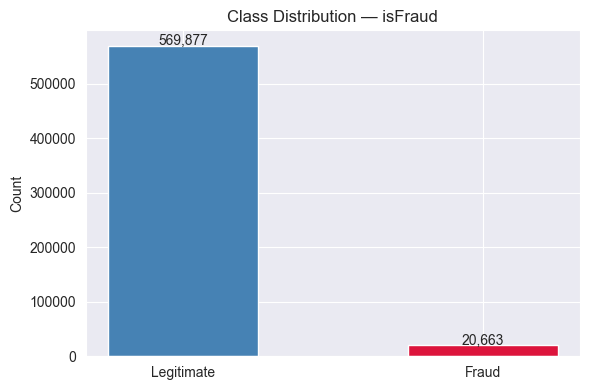

Ratio: 1 fraud per 27 legitimate transactions
Note: Accuracy is useless here. We will use AUC-ROC and F1 in Phase 06.


In [4]:
counts = df['isFraud'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'crimson'], width=0.5)
ax.set_title('Class Distribution — isFraud')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Ratio: 1 fraud per {int(counts[0] / counts[1])} legitimate transactions')
print('Note: Accuracy is useless here. We will use AUC-ROC and F1 in Phase 06.')

### 1.5 — Missing Value Audit

Before fixing anything, we understand the scale of the problem. We count nulls per column and visualize the worst offenders.

Key observation: identity columns (`id_*`, `DeviceType`, `DeviceInfo`) are the most sparse — expected since only 40% of transactions have identity records at all.

Columns with missing values : 414 / 434
Columns fully complete      : 20


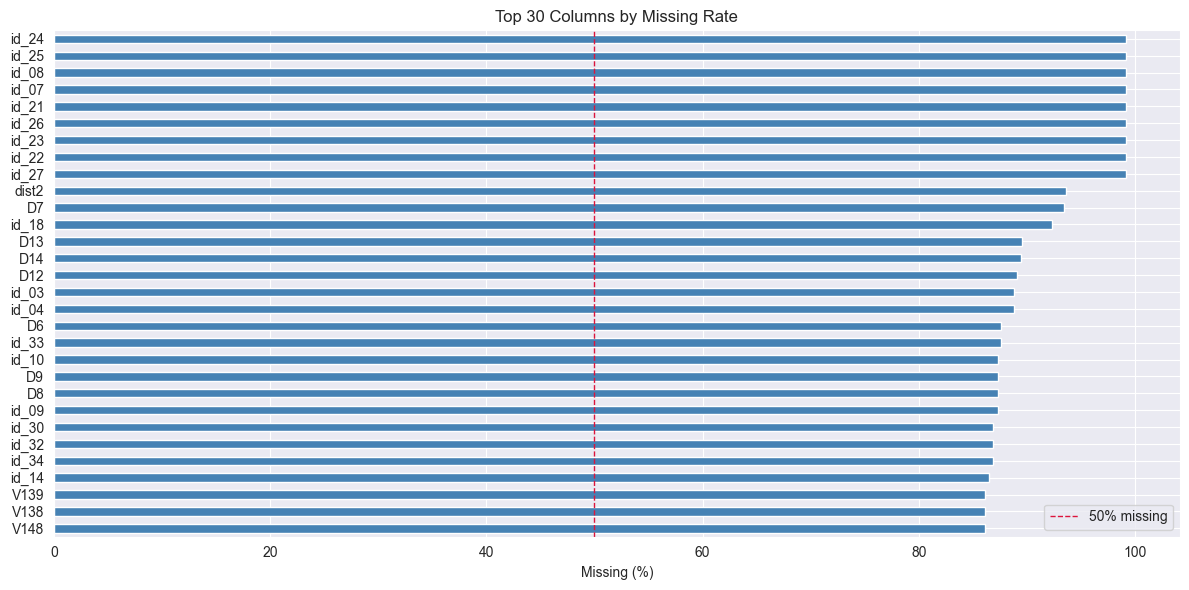

In [5]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print(f'Columns with missing values : {len(null_pct)} / {df.shape[1]}')
print(f'Columns fully complete      : {df.shape[1] - len(null_pct)}')

fig, ax = plt.subplots(figsize=(12, 6))
null_pct.head(30).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='crimson', linestyle='--', linewidth=1, label='50% missing')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 30 Columns by Missing Rate')
ax.legend()
plt.tight_layout()
plt.show()

### 1.6 — Imputation

We use a type-aware strategy:
- **Categorical** → fill with `'unknown'`. Keeps missingness as its own category rather than pretending the data exists.
- **Numerical** → fill with the **column median**. We use median instead of mean because financial data is right-skewed — a few huge transactions would make the mean a bad fill value.

In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns if c != 'isFraud']

df[cat_cols] = df[cat_cols].fillna('unknown')

for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print(f'Categorical columns filled : {len(cat_cols)}')
print(f'Remaining nulls            : {df.isnull().sum().sum()}')

Categorical columns filled : 31
Remaining nulls            : 0


### 1.7 — Label Encoding

GNNs work with numbers. We label-encode all categorical columns so every value in the dataframe is numeric.

Note: columns like `card1`, `DeviceInfo`, and `P_emaildomain` will not be used as flat features — they become **entity nodes** in the graph in Phase 03. We encode them now just to keep the dataframe clean and consistent.

In [7]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Encoded {len(cat_cols)} categorical columns.')
print(f'Remaining object columns: {(df.dtypes == "object").sum()}  (should be 0)')

Encoded 31 categorical columns.
Remaining object columns: 0  (should be 0)


### 1.8 — Normalization

We apply `StandardScaler` to all float columns — centers them at 0 with unit variance. GNNs aggregate neighbor features during message passing, so large feature scales cause unstable gradients. Normalization keeps training stable.

In [8]:
float_cols = [c for c in df.select_dtypes(include='float64').columns
              if c not in {'TransactionID', 'isFraud'}]

scaler = StandardScaler()
df[float_cols] = scaler.fit_transform(df[float_cols])

print(f'Normalized {len(float_cols)} float columns.')
print(f'TransactionAmt after scaling — mean: {df["TransactionAmt"].mean():.4f}, std: {df["TransactionAmt"].std():.4f}')

Normalized 399 float columns.
TransactionAmt after scaling — mean: 0.0000, std: 1.0000


### 1.9 — Entity Column Identification

This is the most important step connecting Phase 01 to Phase 03.

The core idea of relational fraud detection: the **same card, device, or email** appears across multiple transactions. That shared connection becomes a graph edge. Below we list which columns represent these shared entities and how many unique values each has — that tells us how many nodes of each type we'll create.

In [9]:
entity_cols = {
    'card1':         'Card Group A',
    'card2':         'Card Group B',
    'card3':         'Card Group C',
    'card4':         'Card Network (Visa/MC/etc.)',
    'card5':         'Card Group E',
    'card6':         'Card Type (debit/credit)',
    'addr1':         'Billing Zip',
    'addr2':         'Billing Country',
    'P_emaildomain': 'Purchaser Email Domain',
    'R_emaildomain': 'Recipient Email Domain',
    'DeviceType':    'Device Type',
    'DeviceInfo':    'Device Model',
}

print(f'{"Column":<20} {"Role":<30} {"Unique Values":>15}')
print('-' * 68)
for col, role in entity_cols.items():
    if col in df.columns:
        print(f'{col:<20} {role:<30} {df[col].nunique():>15,}')

Column               Role                             Unique Values
--------------------------------------------------------------------
card1                Card Group A                            13,553
card2                Card Group B                               500
card3                Card Group C                               114
card4                Card Network (Visa/MC/etc.)                  5
card5                Card Group E                               119
card6                Card Type (debit/credit)                     5
addr1                Billing Zip                                332
addr2                Billing Country                             74
P_emaildomain        Purchaser Email Domain                      60
R_emaildomain        Recipient Email Domain                      61
DeviceType           Device Type                                  3
DeviceInfo           Device Model                             1,787


### 1.10 — Validation & Save

Final sanity checks before moving on. We confirm no nulls, no object columns, label is intact, IDs are unique, and no infinity values slipped through normalization.

In [10]:
checks = {
    'Zero remaining nulls':       df.isnull().sum().sum() == 0,
    'No object columns':          (df.dtypes == 'object').sum() == 0,
    'isFraud values are 0 and 1': set(df['isFraud'].unique()) == {0, 1},
    'TransactionID is unique':    df['TransactionID'].nunique() == len(df),
    'No inf values':              not np.isinf(df.select_dtypes(include=np.number).values).any(),
}

all_pass = True
for name, result in checks.items():
    status = '✓' if result else '✗'
    print(f'  {status}  {name}')
    if not result:
        all_pass = False

if all_pass:
    df.to_csv('content/sample_data/df_preprocessed.csv', index=False)
    print(f'\nSaved → df_preprocessed.csv  ({df.shape[0]:,} rows x {df.shape[1]} cols)')
    print('Phase 01 complete. Next → Phase 02: Exploratory Data Analysis.')

  ✓  Zero remaining nulls
  ✓  No object columns
  ✓  isFraud values are 0 and 1
  ✓  TransactionID is unique
  ✓  No inf values

Saved → df_preprocessed.csv  (590,540 rows x 434 cols)
Phase 01 complete. Next → Phase 02: Exploratory Data Analysis.
